# Auto MPG — Data Cleaning & Feature Engineering

Pipeline:
1. Drop `car_name` (free-text identifier, would leak make/model)
2. Impute 6 missing `horsepower` values with median
3. Map `origin` numeric codes → readable labels (USA / Europe / Japan)
4. Engineer `power_to_weight`, `displacement_per_cyl`, `is_v8`, `decade`
5. One-hot encode `origin`
6. Save to `data/auto_mpg_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, drop_car_name, impute_horsepower, map_origin,
                   create_features, preprocess_data)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/auto_mpg.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## 2. Missing Values

In [3]:
missing = df.isnull().sum()
print(missing[missing>0])

horsepower    6
dtype: int64


## 3. Drop car_name + Impute horsepower + Map origin

In [4]:
df_step = drop_car_name(df)
df_step = impute_horsepower(df_step, strategy="median")
df_step = map_origin(df_step)
print(f"Shape after step 3: {df_step.shape}")
print(f"Missing values left: {df_step.isnull().sum().sum()}")
df_step.head()

Shape after step 3: (398, 8)
Missing values left: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA


## 4. Distribution Comparison Before/After Imputation

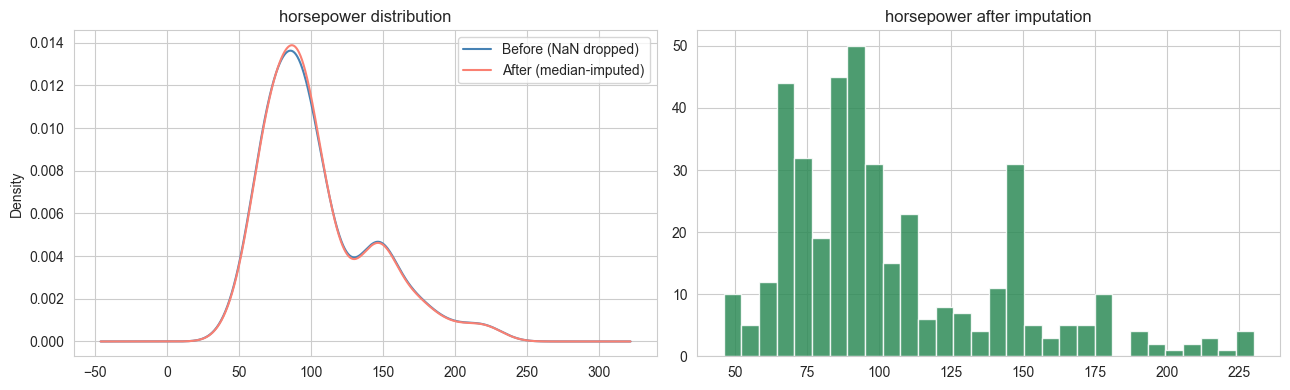

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["horsepower"].dropna().plot(kind="kde", ax=axes[0], color="steelblue", label="Before (NaN dropped)")
df_step["horsepower"].plot(kind="kde", ax=axes[0], color="salmon", label="After (median-imputed)")
axes[0].set_title("horsepower distribution"); axes[0].legend()

axes[1].hist(df_step["horsepower"], bins=30, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].set_title("horsepower after imputation")
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_step)
new_cols = [c for c in df_feat.columns if c not in df_step.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["mpg"]].head()

New features: ['power_to_weight', 'displacement_per_cyl', 'is_v8', 'decade']


,power_to_weight,displacement_per_cyl,is_v8,decade,mpg
0,37.100457,38.375,1,70,18.0
1,44.679123,43.750,1,70,15.0
2,43.655413,39.750,1,70,18.0
3,43.693562,38.000,1,70,16.0
4,40.591476,37.750,1,70,17.0


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_54670/2333742217.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_v8", y="mpg", data=df_feat, palette="Set2", ax=axes[2])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_54670/2333742217.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="decade", y="mpg", data=df_feat, palette="Set2", ax=axes[3])


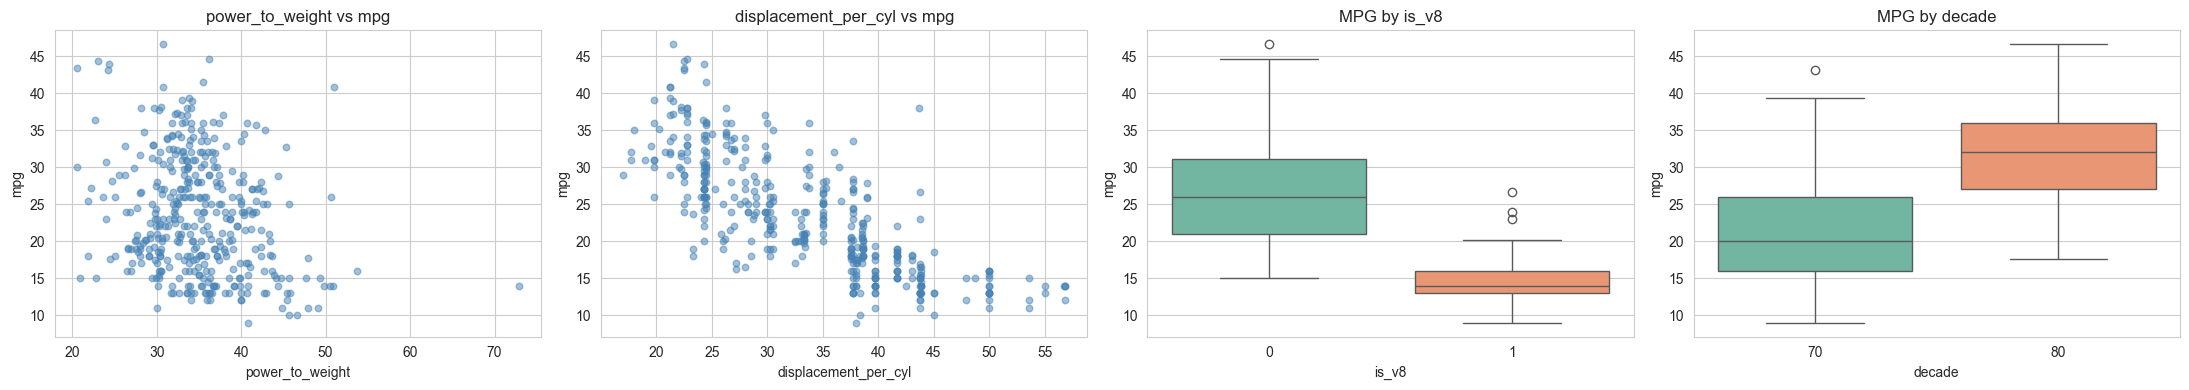

In [7]:
# Visualize new features vs mpg
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
axes[0].scatter(df_feat["power_to_weight"], df_feat["mpg"], alpha=0.5, color="steelblue", s=22)
axes[0].set_xlabel("power_to_weight"); axes[0].set_ylabel("mpg")
axes[0].set_title("power_to_weight vs mpg")

axes[1].scatter(df_feat["displacement_per_cyl"], df_feat["mpg"], alpha=0.5, color="steelblue", s=22)
axes[1].set_xlabel("displacement_per_cyl"); axes[1].set_ylabel("mpg")
axes[1].set_title("displacement_per_cyl vs mpg")

sns.boxplot(x="is_v8", y="mpg", data=df_feat, palette="Set2", ax=axes[2])
axes[2].set_title("MPG by is_v8")

sns.boxplot(x="decade", y="mpg", data=df_feat, palette="Set2", ax=axes[3])
axes[3].set_title("MPG by decade")
plt.tight_layout(); plt.show()

## 6. Run the Full Pipeline

In [8]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (398, 13)
Missing values : 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,power_to_weight,displacement_per_cyl,is_v8,decade,origin_Japan,origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,37.100457,38.375,1,70,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,44.679123,43.750,1,70,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,43.655413,39.750,1,70,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,43.693562,38.000,1,70,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,40.591476,37.750,1,70,0,1


## 7. Sanity Checks & Save

In [9]:
assert df_processed.isnull().sum().sum() == 0
assert "car_name" not in df_processed.columns
assert "mpg" in df_processed.columns
print("All checks passed.")

All checks passed.


In [10]:
df_processed.to_csv("data/auto_mpg_cleaned.csv", index=False)
print(f"Saved data/auto_mpg_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/auto_mpg_cleaned.csv (398 rows, 13 cols)
